# HW01 — Setup tools + first steps in Jupyter / NumPy / Pandas

Этот ноутбук — шаблон для первой домашней работы.

## Как пользоваться
1. Откройте ноутбук в Jupyter/VS Code/Colab.
2. Запускайте ячейки сверху вниз.
3. В местах с `TODO` допишите код.
4. Перед сдачей: **Restart Kernel → Run All** (ноутбук должен выполняться без ошибок).

---


## 1) Проверка окружения

Цель: убедиться, что установлены нужные библиотеки и вы работаете в правильном окружении (kernel).


In [1]:
import sys
import platform

import numpy as np
import pandas as pd

try:
    import sklearn
except Exception as e:
    sklearn = None
    print("⚠️ scikit-learn не импортируется:", e)

print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
print("OS:", platform.platform())

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
if sklearn is not None:
    print("scikit-learn:", sklearn.__version__)


Python: 3.12.12
Executable: /home/evgen2571/dev/ml-course-bsu-famcs/.venv/bin/python
OS: Linux-6.12.74-x86_64-with-glibc2.40
NumPy: 2.4.2
Pandas: 3.0.1
scikit-learn: 1.8.0


## 2) pip внутри ноутбука (инструкция)

Иногда нужно поставить пакет прямо отсюда.

**Локально (рекомендация):**
```python
%pip install -U numpy pandas matplotlib seaborn scikit-learn
```

**Colab / универсально:**
```python
!pip install -U numpy pandas matplotlib seaborn scikit-learn
```

Если после установки импорт не работает — перезапустите kernel.


## 3) NumPy: создаём матрицу 100×5 и считаем статистики

### Задание 3.1
- Создайте случайную матрицу `X` размера **(100, 5)** (например, `np.random.randn`).
- Зафиксируйте seed для воспроизводимости.
- Выведите:
  - `X.shape`
  - `X.dtype`
  - первые 5 строк матрицы

### Задание 3.2
Посчитайте статистики:
- среднее и стандартное отклонение **по всей матрице**
- среднее и стандартное отклонение **по каждому столбцу** (axis=0)
- минимум/максимум по каждому столбцу

> Подсказка: `X.mean()`, `X.mean(axis=0)`, `X.std(axis=0)`, `X.min(axis=0)`, `X.max(axis=0)`.


In [12]:
# TODO: зафиксируйте seed
np.random.seed(21)

# TODO: создайте матрицу 100x5
X = np.random.randn(100, 5)

print("X.shape:", X.shape)
print("X.dtype:", X.dtype)
print("First 5 rows:\n", X[:5])


X.shape: (100, 5)
X.dtype: float64
First 5 rows:
 [[-0.05196425 -0.11119605  1.0417968  -1.25673929  0.74538768]
 [-1.71105376 -0.20586438 -0.23457129  1.12814404 -0.01262595]
 [-0.61320029  1.3736885   1.61099198 -0.68922827  0.69192371]
 [-0.4481156   0.16234247  0.25722913 -1.27545586  0.06400443]
 [-1.06185662 -0.98936839 -0.45772323 -1.98418161 -1.47644212]]


In [13]:
# TODO: статистики по всей матрице
overall_mean = X.mean()
overall_std = X.std()

# TODO: статистики по столбцам
col_mean = X.mean(axis=0)
col_std = X.std(axis=0)
col_min = X.min(axis=0)
col_max = X.max(axis=0)

print("Overall mean:", overall_mean)
print("Overall std:", overall_std)
print("\nPer-column mean:", col_mean)
print("Per-column std:", col_std)
print("Per-column min:", col_min)
print("Per-column max:", col_max)


Overall mean: 0.02493489956811513
Overall std: 0.9958952857140416

Per-column mean: [ 0.1063591   0.23290538 -0.00960643 -0.05755797 -0.14742558]
Per-column std: [0.94799977 0.88492591 1.11452233 1.02163751 0.95065688]
Per-column min: [-1.71105376 -1.78303402 -3.29586553 -2.57356981 -2.37746511]
Per-column max: [2.7550033  2.043847   2.90322608 3.09448155 2.40471405]


## 4) Векторизация: `y = X @ w`

В ML часто встречается линейная комбинация признаков.

### Задание 4.1
- Создайте вектор весов `w` размера (5,)
- Посчитайте `y = X @ w`
- Выведите `y.shape` и несколько первых значений

### Задание 4.2 (мини-метрики регрессии)
- Сгенерируйте “истинную” цель: `y_true = X @ w_true + noise`
- Сгенерируйте предсказание: `y_pred = X @ w_guess`
- Посчитайте **MSE**, **MAE**, **RMSE**
- (Бонус) Посчитайте **R2** вручную

> Подсказка:  
> MSE = mean((y_true - y_pred)^2)  
> MAE = mean(abs(y_true - y_pred))  
> RMSE = sqrt(MSE)  
> R2 = 1 - SS_res / SS_tot


In [4]:
# TODO: веса и линейная комбинация
w = np.random.randn(5)
y = X @ w

print("w:", w)
print("y.shape:", y.shape)
print("y[:5]:", y[:5])


w: [ 0.92617755  1.90941664 -1.39856757  0.56296924 -0.65064257]
y.shape: (100,)
y[:5]: [ 0.29997426  1.10790121 -1.61169274 -2.48647552  0.38401638]


In [14]:
# TODO: "истинные" веса, шум, y_true
w_true = np.array([1.5, -2.0, 0.0, 0.7, 3.0])
noise = 0.1 * np.random.randn(X.shape[0])
y_true = X @ w_true + noise

# TODO: "предсказанные" веса и y_pred (можете взять w_true + небольшой шум)
w_guess = w_true + 0.5 * np.random.randn(5)
y_pred = X @ w_guess

# Метрики
mse = np.mean((y_true - y_pred) ** 2)
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(mse)

# TODO (bonus): R2
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MSE: 0.9033955256853564
MAE: 0.708618862732253
RMSE: 0.9504712124443099
R2: 0.9302551569349222


## 5) Pandas: DataFrame, describe, пропуски, фильтры, groupby

### Задание 5.1
- Создайте DataFrame `df` из матрицы `X`
- Назовите колонки, например: `x0, x1, x2, x3, x4`
- Добавьте столбец `target` = `y_true`

### Задание 5.2
- Выведите `df.head()`, `df.shape`, `df.describe()`
- Проверьте пропуски: `df.isnull().sum()`

### Задание 5.3
- Создайте категориальный столбец (например, бины по `x0`)
- Сделайте `groupby` и посчитайте среднее `target` в группах


In [15]:
# TODO: DataFrame из X
col_names = [f"x{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=col_names)

# TODO: добавьте target
df["target"] = y_true

display(df.head())
print("Shape:", df.shape)
display(df.describe())
print("\nMissing values:\n", df.isnull().sum())


,x0,x1,x2,x3,x4,target
0,-0.051964,-0.111196,1.041797,-1.256739,0.745388,1.478716
1,-1.711054,-0.205864,-0.234571,1.128144,-0.012626,-1.458895
2,-0.613200,1.373688,1.610992,-0.689228,0.691924,-2.186106
3,-0.448116,0.162342,0.257229,-1.275456,0.064004,-1.686484
4,-1.061857,-0.989368,-0.457723,-1.984182,-1.476442,-5.200997


Shape: (100, 6)


,x0,x1,x2,x3,x4,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.106359,0.232905,-0.009606,-0.057558,-0.147426,-0.810212
std,0.952776,0.889384,1.120137,1.026784,0.955446,3.617140
min,-1.711054,-1.783034,-3.295866,-2.573570,-2.377465,-7.963141
25%,-0.650056,-0.439720,-0.721394,-0.697567,-0.919865,-2.785466
50%,0.037016,0.306371,-0.100944,-0.071454,-0.002961,-1.388639
75%,0.713906,0.955766,0.714968,0.546490,0.530473,1.494947
max,2.755003,2.043847,2.903226,3.094482,2.404714,9.434229



Missing values:
 x0        0
x1        0
x2        0
x3        0
x4        0
target    0
dtype: int64


In [16]:
# TODO: пример фильтрации и сортировки (поменяйте условие на своё)
filtered = df[df["x0"] > 0].sort_values("target", ascending=False)
display(filtered.head(10))


,x0,x1,x2,x3,x4,target
42,0.826219,-1.344809,0.334298,0.500805,1.725012,9.434229
16,1.068223,-1.194543,-2.859688,0.424207,1.033613,7.574485
11,0.764650,-0.134385,1.324638,-0.276428,1.679551,6.253277
63,0.637769,-0.284168,1.581727,-0.149887,1.533227,5.959873
40,2.569767,-0.674124,-0.357239,-1.451734,0.595818,5.791886
20,0.945896,-0.750584,-0.794260,0.508398,0.748409,5.476819
13,1.000902,-0.447682,-0.116084,1.169015,0.515614,4.667949
73,0.508445,-1.546855,-1.945222,-1.123140,0.413266,4.189678
8,0.296681,0.220753,-0.423301,1.845615,0.920115,4.175283
41,0.240448,-0.157142,-1.146379,1.964255,0.418694,3.449548


In [17]:
# TODO: создаём бины по x0 и делаем groupby
df["x0_bin"] = pd.cut(df["x0"], bins=4)

grouped = df.groupby("x0_bin")["target"].mean()
display(grouped)


x0_bin
(-1.716, -0.595]   -2.410916
(-0.595, 0.522]    -1.015698
(0.522, 1.638]      0.821393
(1.638, 2.755]      0.653171
Name: target, dtype: float64

## 6) Визуализация: распределения и корреляции

### Задание 6.1
Постройте гистограмму:
- одного признака (например, `x0`) или
- `target`

### Задание 6.2
Постройте тепловую карту корреляций по числовым колонкам.

> Подсказка: `df.corr(numeric_only=True)` (в новых версиях pandas).


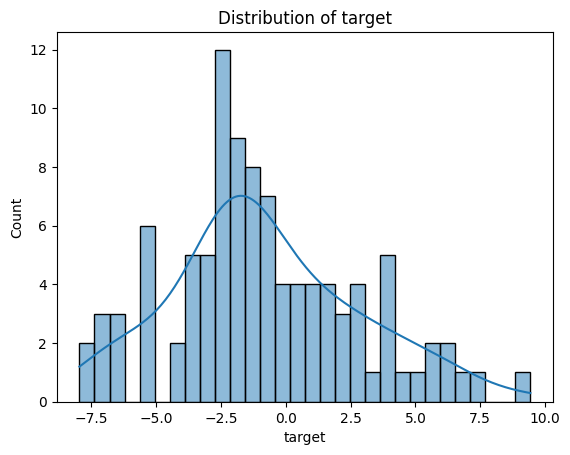

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: гистограмма
plt.figure()
sns.histplot(df["target"], bins=30, kde=True)
plt.title("Distribution of target")
plt.show()


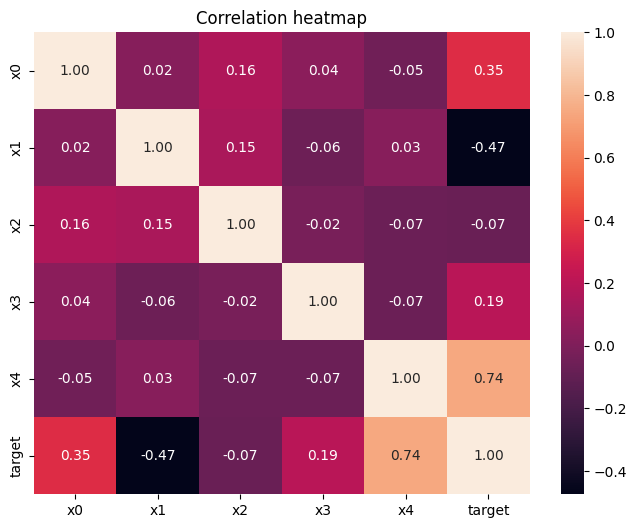

In [19]:
# TODO: корреляции
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()


## 7) Бонус: Iris dataset + простая модель (sklearn)

В лекции упоминался датасет `sklearn.datasets.load_iris`.  
Здесь — небольшой “мини-пайплайн”: загрузка → EDA → train/test split → модель → метрика.

### Задание 7.1
- загрузить iris
- собрать DataFrame
- посмотреть `value_counts()` по классам
- визуализировать (хотя бы bar plot)

### Задание 7.2
- Разбить данные на train/test
- Обучить `LogisticRegression` (или любую другую простую модель)
- Посчитать accuracy на test

Если sklearn не установлен — вернитесь к README и поставьте зависимости.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


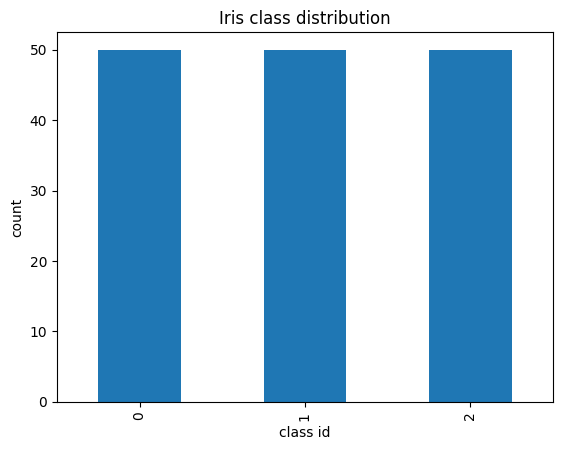

Accuracy: 0.9666666666666667

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [22]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
display(iris_df.head())

print("Class distribution:")
print(iris_df["target"].value_counts())

plt.figure()
iris_df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Iris class distribution")
plt.xlabel("class id")
plt.ylabel("count")
plt.show()

# Train/test split
X_iris = iris_df.drop(columns=["target"])
y_iris = iris_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


## 8) Что закоммитить

- Этот ноутбук с выполненными заданиями
- README с инструкциями
- (желательно) `requirements.txt` и `.gitignore` в корне репозитория

Перед коммитом проверьте:
- ноутбук запускается без ошибок (Restart & Run All)
- нет огромных выводов (тысячи строк) и больших файлов в репозитории
